<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/). 
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA). 
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [44]:
# Import torch
import torch
import torch.nn as nn

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device  = "mps" if torch.mps.is_available() else "cpu"
device

2.10.0


'mps'

## 1. What are 3 areas in industry where computer vision is currently being used?

### > 1. Military and Security
### > 2. Healthcare 
### > 3. Autonomus Cars
### > 4. Humanoid Robots 



## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find. 

Overfitting is that model learns too closely patterns specific to training data
And causes poor performance on new unseen data 

Because of overly complex models or wrong parameters or insufficient training data

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each. 
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

1. Inceasing training data volume 
2. Using cross-validation
3. Applying Regularization
4. Reduce model complexity

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

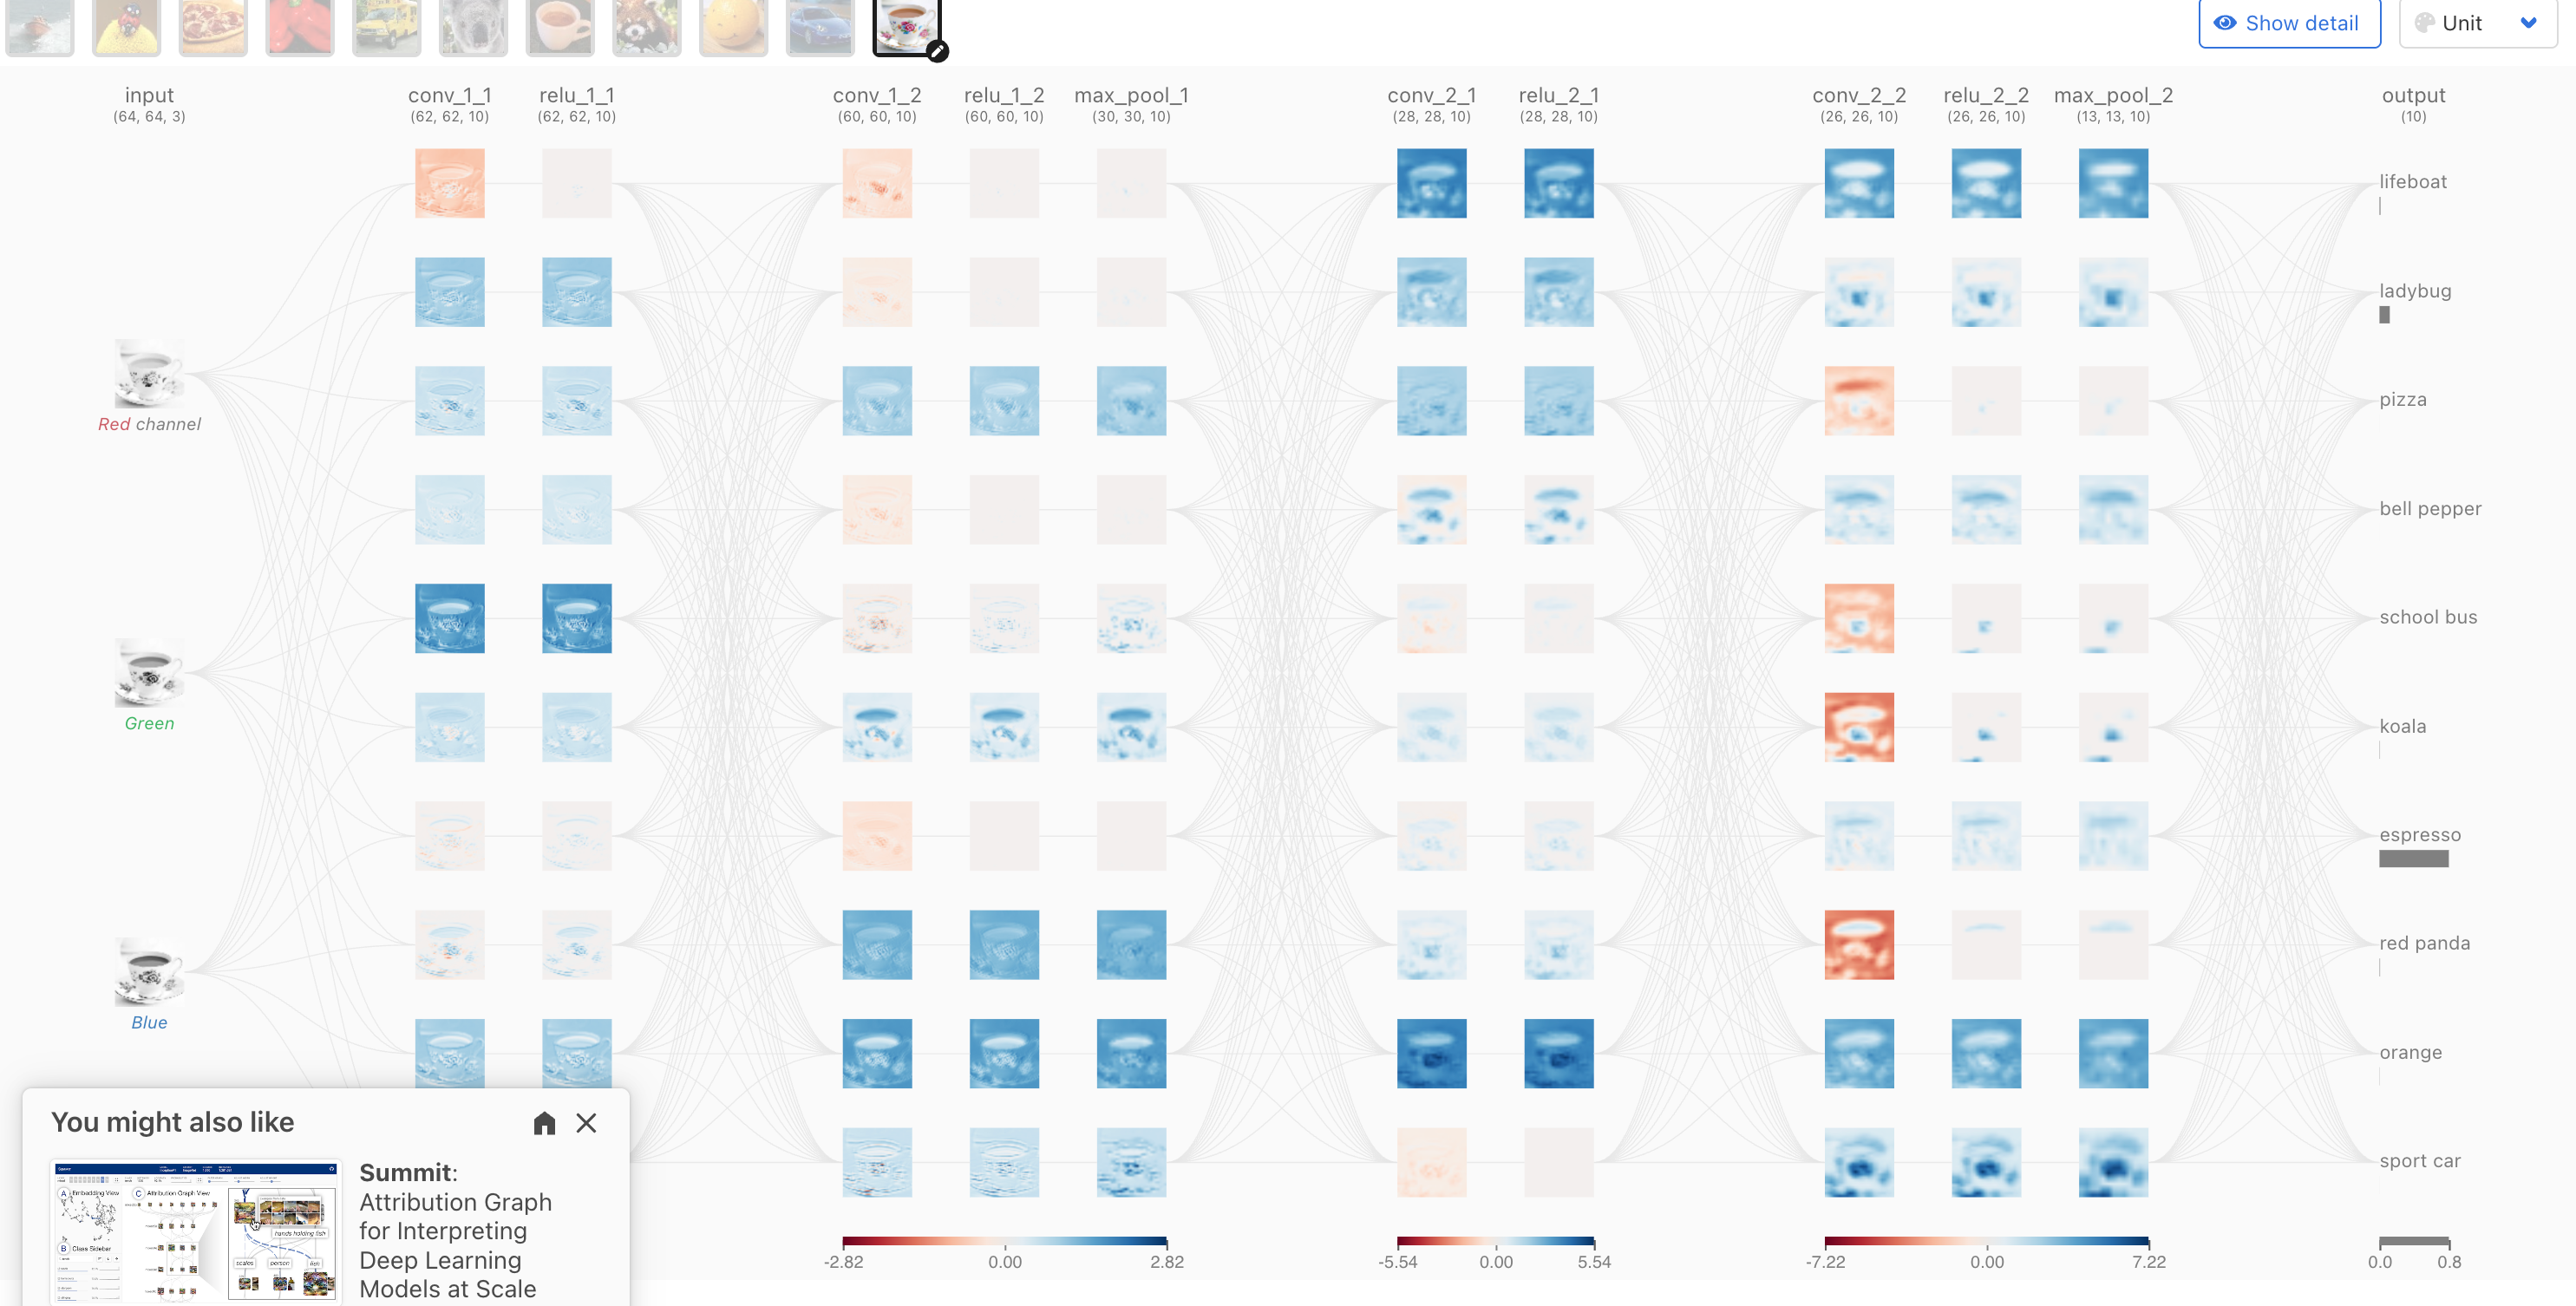

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [45]:
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

train_data = MNIST(
    root="data",
    train=True,
    transform=ToTensor(),
    target_transform=None,
    download=True
)

test_data = MNIST(
    root="data",
    train=False,
    transform=ToTensor(),
    target_transform=None,
    download=True
)


## 6. Visualize at least 5 different samples of the MNIST training dataset.

In [46]:
train_data.data[:100][0].shape

torch.Size([28, 28])

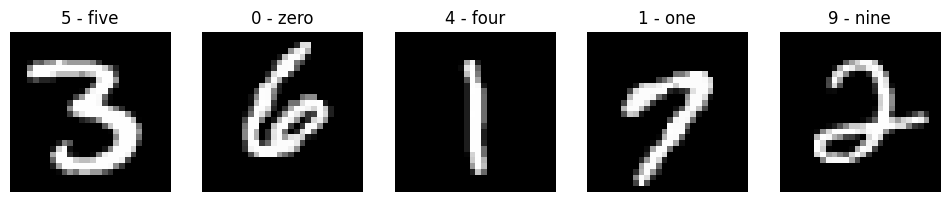

In [47]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(12, 3))

for i, image in enumerate(train_data.data[12:17]):
    ax[i].imshow(image.numpy(), cmap="gray")
    ax[i].set_title(train_data.classes[train_data.targets[i]])
    ax[i].axis("off")

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [48]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=32,
    shuffle=False
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=32,
    shuffle=False
)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [85]:

class TinyVGG(nn.Module):
    def __init__(self, in_channels: int, hidden_units: int, out_channels: int):
        super().__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ), nn.ReLU(),
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ), nn.ReLU(), nn.MaxPool2d(2)
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ), nn.ReLU(),
        )

        self.conv_block4 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ), nn.ReLU(), nn.MaxPool2d(2)
        )

        self.classifer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features=hidden_units*7*7,
                out_features=out_channels
            )
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_block1(x)
        x = self.conv_block2(x)

        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.classifer(x)

        return x



TinyVGG


__main__.TinyVGG

In [86]:
from helper_functions import accuracy_fn
from tqdm.auto import tqdm

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [87]:
def train_step(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    dataloader: DataLoader,
    device: torch.device = device
) -> tuple:
    
    loss = 0
    acc = 0

    model.train()
    for X, y in tqdm(dataloader):
        X, y = X.to(device), y.to(device)
        y_logits = model(X)

        _loss = loss_fn(y_logits, y)
        loss += _loss
        acc += accuracy_fn(y, torch.argmax(y_logits, dim=1))

        optimizer.zero_grad()
        _loss.backward()
        optimizer.step()


    length = len(dataloader)

    return loss / length, acc / length

In [88]:
modelvgg = TinyVGG(
    in_channels=1,
    hidden_units=10,
    out_channels=10
).to(device)

optimizer = torch.optim.SGD(modelvgg.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(1, 4):
    loss, acc = train_step(
        model=modelvgg,
        optimizer=optimizer,
        loss_fn=loss_fn,
        dataloader=train_dataloader
    )

    print(f"\nEpoch: {epoch} | Loss: {loss} | Accuracy: {acc}\n"+"-"*20)


  0%|          | 0/1875 [00:00<?, ?it/s]


Epoch: 1 | Loss: 0.21571384370326996 | Accuracy: 93.14166666666667
--------------------


  0%|          | 0/1875 [00:00<?, ?it/s]


Epoch: 2 | Loss: 0.06960251927375793 | Accuracy: 97.84333333333333
--------------------


  0%|          | 0/1875 [00:00<?, ?it/s]


Epoch: 3 | Loss: 0.05364133417606354 | Accuracy: 98.335
--------------------


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset. 
* Then plot some predictions where the model was wrong alongside what the label of the image should've been. 
* After visualing these predictions do you think it's more of a modelling error or a data error? 
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?